## Part1 Reproduce the Cumulants in table1 and table2 of the blog.

In [1]:
import math
import cmath
from functools import lru_cache

import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# PART 1
# Build table1 / table2 / table3
# Save table3 into arrays / lists / dicts for later use
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.precision", 6)

# ----------------------------
# Helpers: normalization
# ----------------------------
def normalize_unit_variance(points):
    pts = np.asarray(points, dtype=np.complex128)
    pts = pts - pts.mean()
    var = np.mean(np.abs(pts) ** 2)
    return pts / np.sqrt(var)

# ----------------------------
# Helpers: set partitions
# ----------------------------
def _set_partitions(seq):
    if len(seq) == 1:
        return [[[seq[0]]]]

    first = seq[0]
    out = []
    seen = set()

    for part in _set_partitions(seq[1:]):
        cand = [[first]] + [b[:] for b in part]
        key = tuple(sorted(tuple(sorted(b)) for b in cand))
        if key not in seen:
            seen.add(key)
            out.append([list(b) for b in key])

        for i in range(len(part)):
            cand = [b[:] for b in part]
            cand[i] = [first] + cand[i]
            key = tuple(sorted(tuple(sorted(b)) for b in cand))
            if key not in seen:
                seen.add(key)
                out.append([list(b) for b in key])

    return out

@lru_cache(maxsize=None)
def partition_block_signatures(n_total, n_nonconj):
    idx = list(range(n_total))
    signatures = []

    for part in _set_partitions(idx):
        coeff = ((-1) ** (len(part) - 1)) * math.factorial(len(part) - 1)
        block_sig = []
        for block in part:
            p = sum(1 for j in block if j < n_nonconj)
            q = len(block) - p
            block_sig.append((p, q))
        signatures.append((coeff, tuple(sorted(block_sig))))

    return tuple(signatures)

# ----------------------------
# Moments and cumulants
# ----------------------------
def mixed_moment(points, p, q):
    pts = np.asarray(points, dtype=np.complex128)
    return np.mean((pts ** p) * (np.conj(pts) ** q))

def mixed_cumulant(points, n, m):
    n_nonconj = n - m
    cache_mom = {}
    out = 0.0 + 0.0j

    for coeff, blocks in partition_block_signatures(n, n_nonconj):
        prod = 1.0 + 0.0j
        for p, q in blocks:
            key = (p, q)
            if key not in cache_mom:
                cache_mom[key] = mixed_moment(points, p, q)
            prod *= cache_mom[key]
        out += coeff * prod

    if abs(out.imag) < 1e-12:
        out = out.real + 0j
    if abs(out.real) < 1e-12:
        out = 0.0 + 1j * out.imag
    return out

# ----------------------------
# Constellation definitions
# ----------------------------
const_real = {
    "BPSK": [-1, +1],
    "4ASK": [-3, -1, +1, +3],
    "8ASK": [-7, -5, -3, -1, +1, +3, +5, +7],
}

const_complex_raw = {
    "BPSK": [-1, +1],
    "QPSK": [1, 1j, -1, -1j],   # Chad blog's QPSK definition
    "8PSK": [cmath.exp(1j * 2 * math.pi * k / 8) for k in range(8)],
    "MPSK, M > 8": [cmath.exp(1j * 2 * math.pi * k / 16) for k in range(16)],
    "4QAM": [1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j],
    "8QAM": [1, -1, 1j, -1j, 1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j],
    "16QAM": [x + 1j * y for x in [-3, -1, 1, 3] for y in [-3, -1, 1, 3]],
    "32QAM": [x + 1j * y
              for x in [-5, -3, -1, 1, 3, 5]
              for y in [-5, -3, -1, 1, 3, 5]
              if not (abs(x) == 5 and abs(y) == 5)],
    "64QAM": [x + 1j * y
              for x in [-7, -5, -3, -1, 1, 3, 5, 7]
              for y in [-7, -5, -3, -1, 1, 3, 5, 7]],
    "128QAM": [x + 1j * y
               for x in [-11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11]
               for y in [-11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11]
               if not (abs(x) in [9, 11] and abs(y) in [9, 11])],
    "256QAM": [x + 1j * y
               for x in range(-15, 16, 2)
               for y in range(-15, 16, 2)],
}

const_real = {k: normalize_unit_variance(v) for k, v in const_real.items()}
const_complex = {k: normalize_unit_variance(v) for k, v in const_complex_raw.items()}

# ============================================================
# Table 1
# ============================================================
orders_real = [2, 4, 6, 8, 10]
rows_t1 = []

for name, pts in const_real.items():
    moments = [mixed_moment(pts, n, 0).real for n in orders_real]
    cumulants = [mixed_cumulant(pts, n, 0).real for n in orders_real]
    rows_t1.append([name, "M"] + moments)
    rows_t1.append([name, "C"] + cumulants)

table1 = pd.DataFrame(rows_t1, columns=["Constellation", "M/C", 2, 4, 6, 8, 10])

# ============================================================
# Table 2
# ============================================================
paired_specs = [
    ("C(4,0)=C(4,4)",   4,  [0, 4]),
    ("C(4,2)",          4,  [2]),
    ("C(6,1)=C(6,5)",   6,  [1, 5]),
    ("C(6,3)",          6,  [3]),
    ("C(8,0)=C(8,8)",   8,  [0, 8]),
    ("C(8,2)=C(8,6)",   8,  [2, 6]),
    ("C(8,4)",          8,  [4]),
    ("C(10,1)=C(10,9)", 10, [1, 9]),
    ("C(10,3)=C(10,7)", 10, [3, 7]),
    ("C(10,5)",         10, [5]),
]

table2_order = [
    "BPSK",
    "QPSK",
    "8PSK",
    "MPSK, M > 8",
    "4QAM",
    "8QAM",
    "16QAM",
    "32QAM",
    "64QAM",
    "128QAM",
    "256QAM",
]

rows_t2 = []
for name in table2_order:
    pts = const_complex[name]
    row = [name]
    for label, n, m_list in paired_specs:
        vals = [mixed_cumulant(pts, n, m).real for m in m_list]
        row.append(vals[0])
    rows_t2.append(row)

table2 = pd.DataFrame(rows_t2, columns=["PDF"] + [x[0] for x in paired_specs])

# ============================================================
# Table 3: full 24 C_a(n,m)
# ============================================================
full_nm = (
    [(2, m) for m in range(3)] +
    [(4, m) for m in range(5)] +
    [(6, m) for m in range(7)] +
    [(8, m) for m in range(9)]
)

table3_cols = [f"C({n},{m})" for (n, m) in full_nm]

table3_order = [
    "BPSK",
    "QPSK",
    "8PSK",
    "MPSK, M > 8",
    "4QAM",
    "8QAM",
    "16QAM",
    "32QAM",
    "64QAM",
    "128QAM",
    "256QAM",
]

rows_t3 = []
for name in table3_order:
    pts = const_complex[name]
    vals = [mixed_cumulant(pts, n, m).real for (n, m) in full_nm]
    rows_t3.append([name] + vals)

table3 = pd.DataFrame(rows_t3, columns=["PDF"] + table3_cols)

# ============================================================
# Save table3 for later use
# ============================================================
table3_pdf_list = table3["PDF"].tolist()
table3_col_labels = table3_cols[:]                              # list[str], len=24
table3_value_array = table3[table3_cols].to_numpy(dtype=float) # np.ndarray, shape=(11,24)
table3_value_list = table3[table3_cols].values.tolist()        # list[list]

# PDF -> 24-value row list
table3_row_list_dict = {
    pdf: table3.loc[table3["PDF"] == pdf, table3_cols].iloc[0].tolist()
    for pdf in table3_pdf_list
}

# PDF -> {(n,m): value}
table3_row_nm_dict = {
    pdf: {nm: val for nm, val in zip(full_nm, table3_row_list_dict[pdf])}
    for pdf in table3_pdf_list
}

# Direct exports
table3_bpsk_array = np.array(table3_row_list_dict["BPSK"], dtype=float)
table3_qpsk_array = np.array(table3_row_list_dict["QPSK"], dtype=float)

table3_bpsk_nm_dict = table3_row_nm_dict["BPSK"]
table3_qpsk_nm_dict = table3_row_nm_dict["QPSK"]

# ============================================================
# Rounded display copies
# ============================================================
table1_disp = table1.copy()
for c in [2, 4, 6, 8, 10]:
    table1_disp[c] = table1_disp[c].map(lambda x: round(float(x), 2))

table2_disp = table2.copy()
for c in table2_disp.columns[1:]:
    table2_disp[c] = table2_disp[c].map(lambda x: round(float(x), 2))

table3_disp = table3.copy()
for c in table3_disp.columns[1:]:
    table3_disp[c] = table3_disp[c].map(lambda x: round(float(x), 2))

# ============================================================
# Display
# ============================================================
print("Table 1")
display(table1_disp)

print("\nTable 2")
display(table2_disp)

print("\nTable 3")
display(table3_disp)


Table 1


,Constellation,M/C,2,4,6,8,10
0,BPSK,M,1.0,1.00,1.00,1.00,1.00
1,BPSK,C,1.0,-2.00,16.00,-272.00,7936.00
2,4ASK,M,1.0,1.64,2.92,5.25,9.45
3,4ASK,C,1.0,-1.36,8.32,-111.85,2603.01
4,8ASK,M,1.0,1.76,3.62,7.92,17.89
5,8ASK,C,1.0,-1.24,7.19,-92.02,2039.53



Table 2


,PDF,"C(4,0)=C(4,4)","C(4,2)","C(6,1)=C(6,5)","C(6,3)","C(8,0)=C(8,8)","C(8,2)=C(8,6)","C(8,4)","C(10,1)=C(10,9)","C(10,3)=C(10,7)","C(10,5)"
0,BPSK,-2.00,-2.00,16.00,16.00,-272.00,-272.00,-272.00,7936.00,7936.00,7936.00
1,QPSK,1.00,-1.00,-4.00,4.00,-34.00,34.00,-34.00,496.00,-496.00,496.00
2,8PSK,0.00,-1.00,0.00,4.00,1.00,0.00,-33.00,-8.00,0.00,456.00
3,"MPSK, M > 8",0.00,-1.00,0.00,4.00,0.00,0.00,-33.00,0.00,0.00,456.00
4,4QAM,-1.00,-1.00,4.00,4.00,-34.00,-34.00,-34.00,496.00,496.00,496.00
5,8QAM,-0.67,-0.89,2.30,3.33,-13.88,-17.93,-26.32,179.95,244.77,351.80
6,16QAM,-0.68,-0.68,2.08,2.08,-13.98,-13.98,-13.98,162.69,162.69,162.69
7,32QAM,-0.19,-0.69,0.57,2.11,-1.99,-3.84,-13.79,18.92,44.93,152.74
8,64QAM,-0.62,-0.62,1.80,1.80,-11.50,-11.50,-11.50,127.47,127.47,127.47
9,128QAM,-0.18,-0.66,0.53,1.96,-1.81,-3.48,-12.49,16.72,39.72,135.00



Table 3


,PDF,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
0,BPSK,1.0,1.0,1.0,-2.00,-2.0,-2.00,-2.0,-2.00,16.0,16.00,16.0,16.00,16.0,16.00,16.0,-272.00,-272.0,-272.00,-272.0,-272.00,-272.0,-272.00,-272.0,-272.00
1,QPSK,0.0,1.0,0.0,1.00,0.0,-1.00,0.0,1.00,0.0,-4.00,0.0,4.00,0.0,-4.00,0.0,-34.00,0.0,34.00,0.0,-34.00,0.0,34.00,0.0,-34.00
2,8PSK,0.0,1.0,0.0,0.00,0.0,-1.00,0.0,0.00,0.0,0.00,0.0,4.00,0.0,0.00,0.0,1.00,0.0,0.00,0.0,-33.00,0.0,0.00,0.0,1.00
3,"MPSK, M > 8",0.0,1.0,0.0,0.00,0.0,-1.00,0.0,0.00,0.0,0.00,0.0,4.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,-33.00,0.0,0.00,0.0,0.00
4,4QAM,0.0,1.0,0.0,-1.00,0.0,-1.00,0.0,-1.00,0.0,4.00,0.0,4.00,0.0,4.00,0.0,-34.00,0.0,-34.00,0.0,-34.00,0.0,-34.00,0.0,-34.00
5,8QAM,0.0,1.0,0.0,-0.67,0.0,-0.89,0.0,-0.67,0.0,2.30,0.0,3.33,0.0,2.30,0.0,-13.88,0.0,-17.93,0.0,-26.32,0.0,-17.93,0.0,-13.88
6,16QAM,0.0,1.0,0.0,-0.68,0.0,-0.68,0.0,-0.68,0.0,2.08,0.0,2.08,0.0,2.08,0.0,-13.98,0.0,-13.98,0.0,-13.98,0.0,-13.98,0.0,-13.98
7,32QAM,0.0,1.0,0.0,-0.19,0.0,-0.69,0.0,-0.19,0.0,0.57,0.0,2.11,0.0,0.57,0.0,-1.99,0.0,-3.84,0.0,-13.79,0.0,-3.84,0.0,-1.99
8,64QAM,0.0,1.0,0.0,-0.62,0.0,-0.62,0.0,-0.62,0.0,1.80,0.0,1.80,0.0,1.80,0.0,-11.50,0.0,-11.50,0.0,-11.50,0.0,-11.50,0.0,-11.50
9,128QAM,0.0,1.0,0.0,-0.18,0.0,-0.66,0.0,-0.18,0.0,0.53,0.0,1.96,0.0,0.53,0.0,-1.81,0.0,-3.48,0.0,-12.49,0.0,-3.48,0.0,-1.81


## Part 2 Using SQRC signal (rolloff = 0.35) to compare the theoretical calculations with the Eq10,11 estimators.

$$
C_{s_{BB}}^\alpha(\tau;n,m)
=
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p^{(*)_j}(t+\tau_j)
\right]
e^{-i2\pi\alpha t}\,dt
\;\xrightarrow{\;\tau_1=\cdots=\tau_n=0\;}
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p^{(*)_j}(t)
\right]
e^{-i2\pi\alpha t}\,dt
$$

$$
\;\xrightarrow{\;p(t)\in\mathbb{R}\;\Rightarrow\;p^*(t)=p(t)\;}
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p(t)
\right]
e^{-i2\pi\alpha t}\,dt
=
\frac{C_a(n,m)}{T_0}
\int
p(t)^n\,e^{-i2\pi\alpha t}\,dt
$$



$$
\;\xrightarrow{\;\alpha = k/T_0\;}
C_{s_{BB}}^{k/T_0}(0;n,m)
=
\frac{C_a(n,m)}{T_0}
\int
p(t)^n\,e^{-i2\pi(k/T_0)t}\,dt
$$

$$
\;\xrightarrow{\;\text{under the current normalized-pulse implementation}\;}
\text{let }
p(t)=g_\beta\!\left(\frac{t}{T_0}\right)
$$

$$
\Rightarrow\quad
C_{s_{BB}}^{k/T_0}(0;n,m)
=
\frac{C_a(n,m)}{T_0}
\int
\left[
g_\beta\!\left(\frac{t}{T_0}\right)
\right]^n
e^{-i2\pi(k/T_0)t}\,dt
$$

$$
\;\xrightarrow{\;u=t/T_0,\;t=T_0u,\;dt=T_0\,du\;}
\frac{C_a(n,m)}{T_0}
\int
g_\beta(u)^n\,
e^{-i2\pi(k/T_0)(T_0u)}\,
T_0\,du
$$

$$
=
\frac{C_a(n,m)}{T_0}
\int
g_\beta(u)^n\,
e^{-i2\pi ku}\,
T_0\,du
$$

$$
\;\xrightarrow{\;\frac{1}{T_0}\cdot T_0 = 1\;}
C_a(n,m)
\int
g_\beta(u)^n\,e^{-i2\pi ku}\,du
$$

$$
\boxed{
C_{s_{BB}}^{k/T_0}(0;n,m)
=
C_a(n,m)
\int
g_\beta(u)^n\,e^{-i2\pi ku}\,du
}
$$

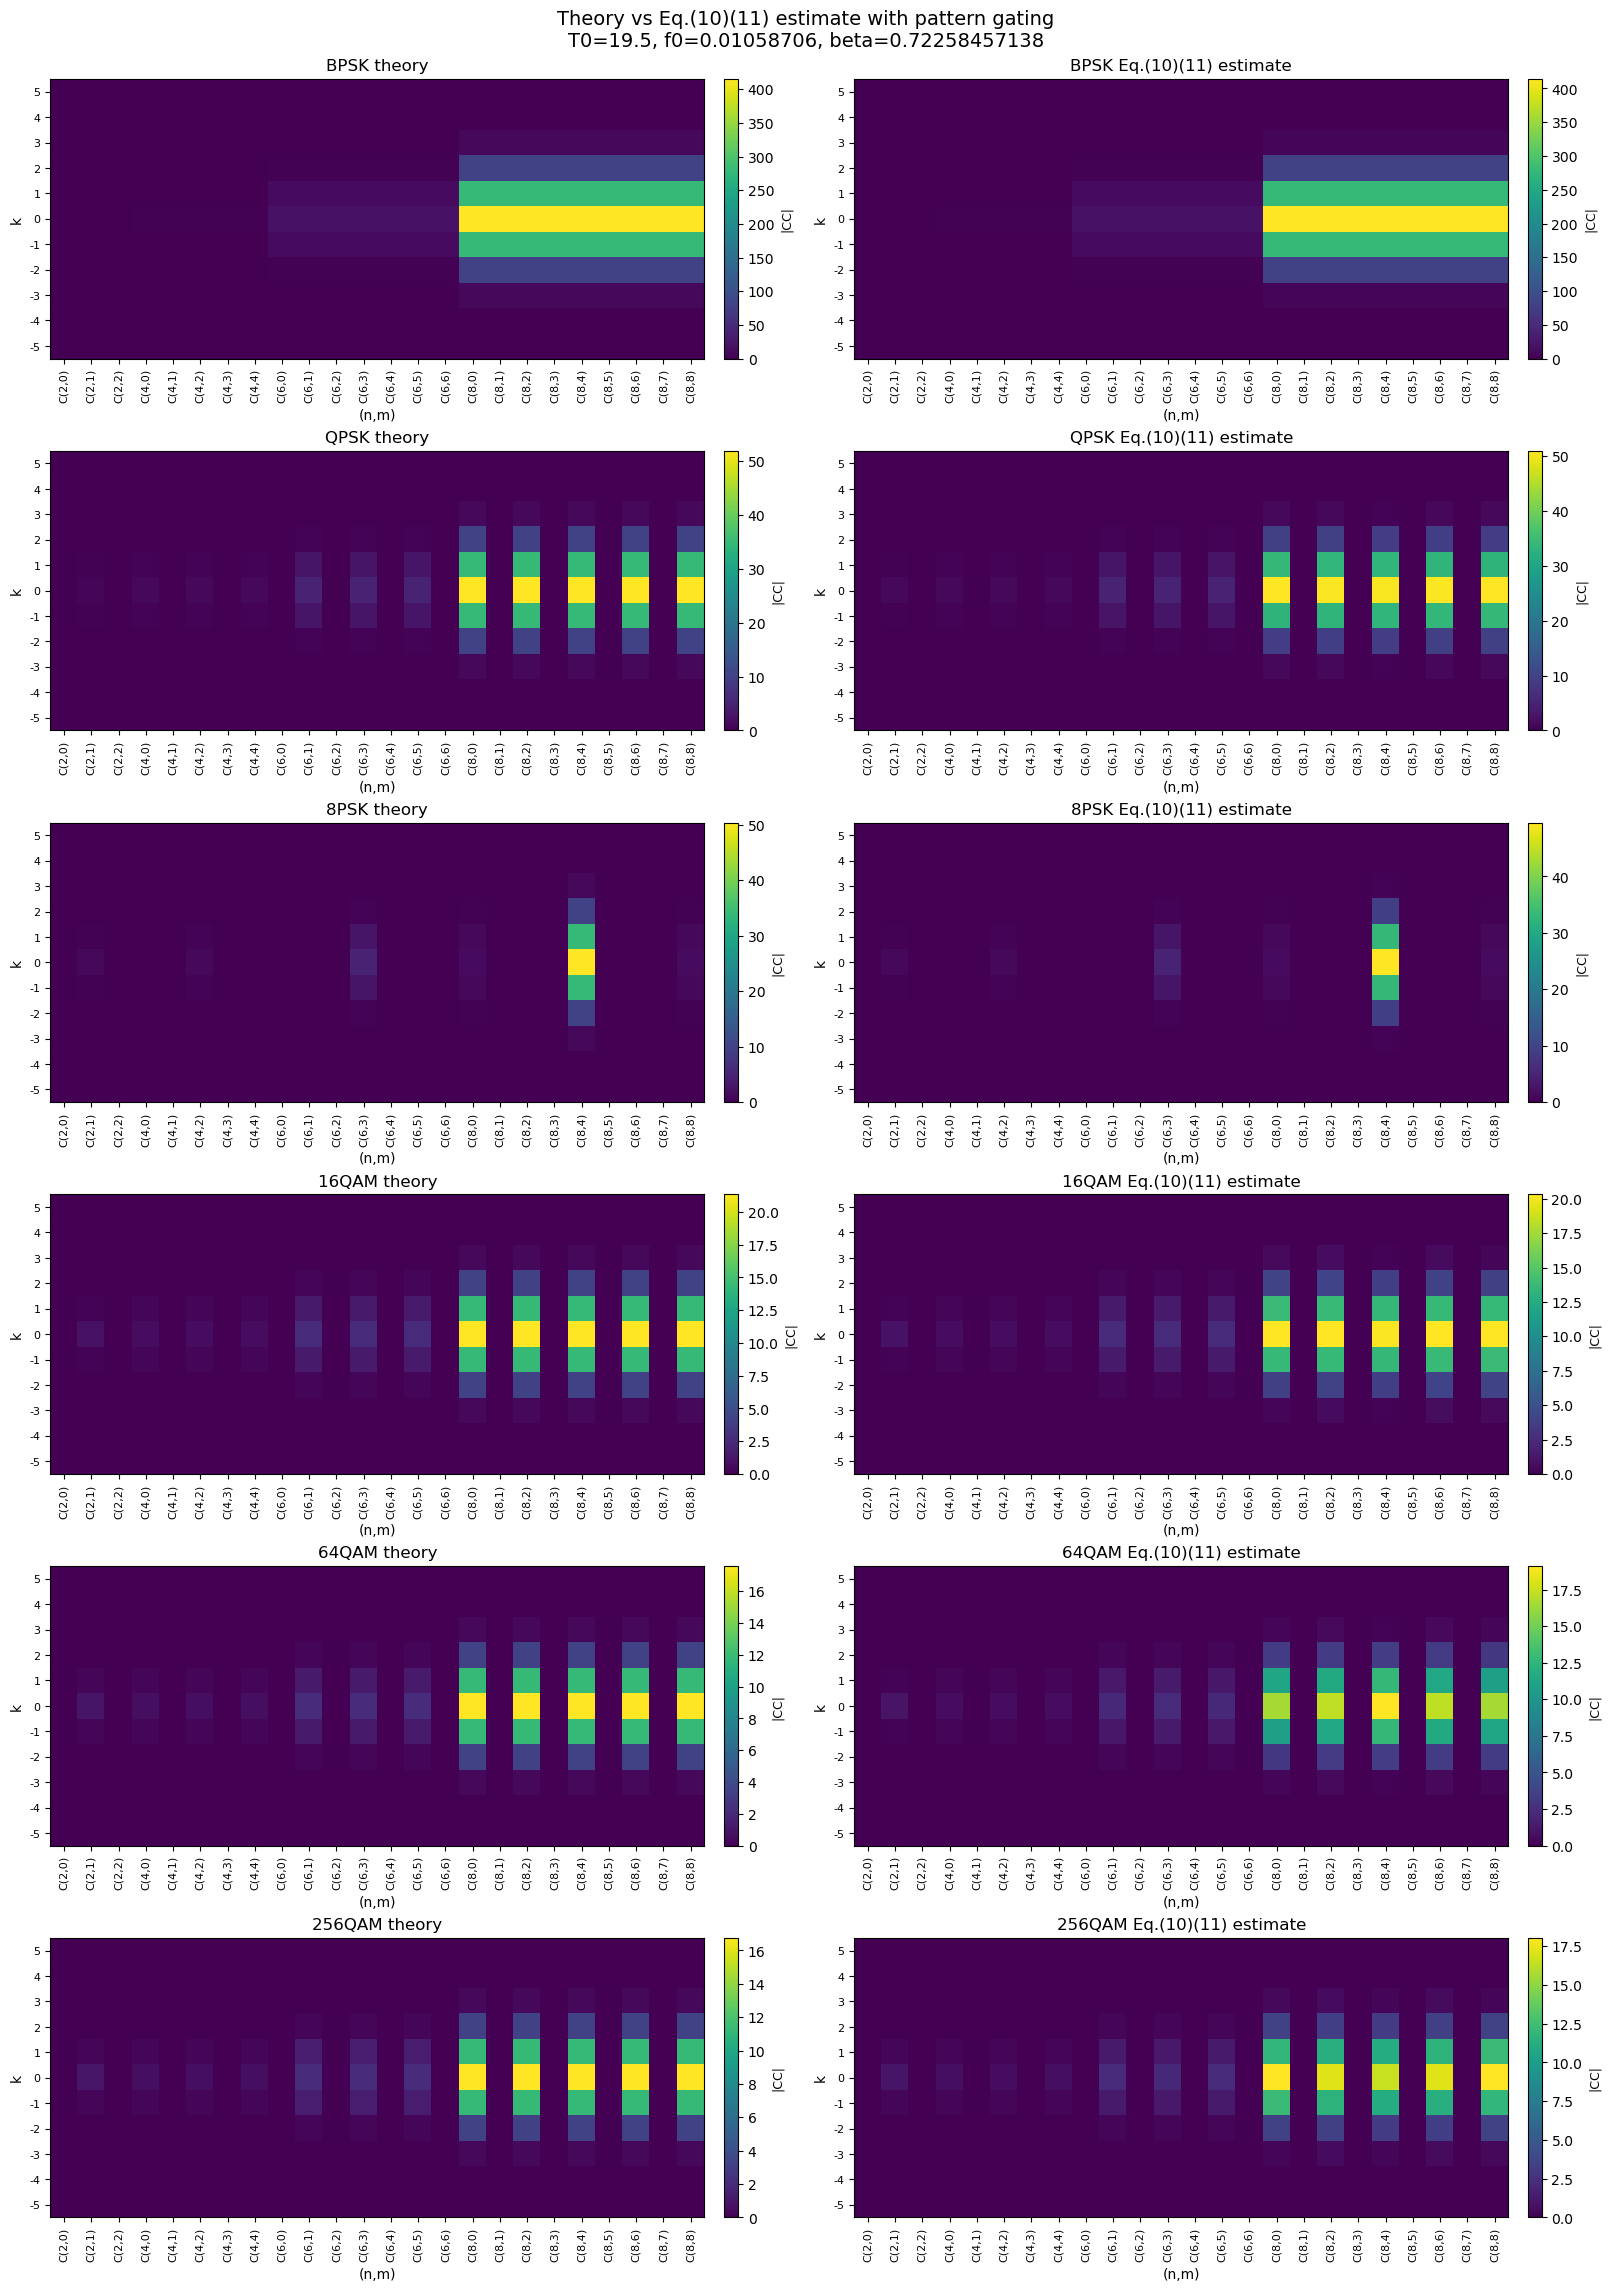


================ BPSK theory matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020
-2,0.000000,0.000000,0.000000,0.066002,0.066002,0.066002,0.066002,0.066002,2.160256,2.160256,2.160256,2.160256,2.160256,2.160256,2.160256,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018
-1,0.230011,0.230011,0.230011,0.955394,0.955394,0.955394,0.955394,0.955394,11.548423,11.548423,11.548423,11.548423,11.548423,11.548423,11.548423,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232
0,1.000000,1.000000,1.000000,2.069873,2.069873,2.069873,2.069873,2.069873,19.578037,19.578037,19.578037,19.578037,19.578037,19.578037,19.578037,415.311956,415.311956,415.311956,415.311956,415.311956,415.311956,415.311956,415.311956,415.311956
1,0.230011,0.230011,0.230011,0.955394,0.955394,0.955394,0.955394,0.955394,11.548423,11.548423,11.548423,11.548423,11.548423,11.548423,11.548423,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232,278.005232
2,0.000000,0.000000,0.000000,0.066002,0.066002,0.066002,0.066002,0.066002,2.160256,2.160256,2.160256,2.160256,2.160256,2.160256,2.160256,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018,80.259018
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020,8.727020
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



================ BPSK Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695
-2,0.000000,0.000000,0.000000,0.065549,0.065549,0.065549,0.065549,0.065549,2.146286,2.146286,2.146286,2.146286,2.146286,2.146286,2.146286,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283
-1,0.229124,0.229124,0.229124,0.952428,0.952428,0.952428,0.952428,0.952428,11.508782,11.508782,11.508782,11.508782,11.508782,11.508782,11.508782,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781
0,1.000000,1.000000,1.000000,2.067982,2.067982,2.067982,2.067982,2.067982,19.538474,19.538474,19.538474,19.538474,19.538474,19.538474,19.538474,414.009516,414.009516,414.009516,414.009516,414.009516,414.009516,414.009516,414.009516,414.009516
1,0.229124,0.229124,0.229124,0.952428,0.952428,0.952428,0.952428,0.952428,11.508782,11.508782,11.508782,11.508782,11.508782,11.508782,11.508782,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781,276.859781
2,0.000000,0.000000,0.000000,0.065549,0.065549,0.065549,0.065549,0.065549,2.146286,2.146286,2.146286,2.146286,2.146286,2.146286,2.146286,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283,79.469283
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695,7.485695
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



================ BPSK absolute error =================


...

,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.351982,0.0,0.351982,0.0,0.351982,0.0,0.351982,0.0,0.351982
-2,0.0,0.000000,0.0,0.019956,0.0,0.019956,0.0,0.019956,0.0,0.234190,0.0,0.234190,0.0,0.234190,0.0,3.237038,0.0,3.237038,0.0,3.237038,0.0,3.237038,0.0,3.237038
-1,0.0,0.230011,0.0,0.288866,0.0,0.288866,0.0,0.288866,0.0,1.251945,0.0,1.251945,0.0,1.251945,0.0,11.212616,0.0,11.212616,0.0,11.212616,0.0,11.212616,0.0,11.212616
0,0.0,1.000000,0.0,0.625832,0.0,0.625832,0.0,0.625832,0.0,2.122422,0.0,2.122422,0.0,2.122422,0.0,16.750525,0.0,16.750525,0.0,16.750525,0.0,16.750525,0.0,16.750525
1,0.0,0.230011,0.0,0.288866,0.0,0.288866,0.0,0.288866,0.0,1.251945,0.0,1.251945,0.0,1.251945,0.0,11.212616,0.0,11.212616,0.0,11.212616,0.0,11.212616,0.0,11.212616
2,0.0,0.000000,0.0,0.019956,0.0,0.019956,0.0,0.019956,0.0,0.234190,0.0,0.234190,0.0,0.234190,0.0,3.237038,0.0,3.237038,0.0,3.237038,0.0,3.237038,0.0,3.237038
3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.351982,0.0,0.351982,0.0,0.351982,0.0,0.351982,0.0,0.351982
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000



================ 256QAM Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.333029,0.0,0.523794,0.0,0.340783,0.0,0.558682,0.0,0.383608
-2,0.0,0.000000,0.0,0.018593,0.0,0.020646,0.0,0.022347,0.0,0.242658,0.0,0.240462,0.0,0.238830,0.0,3.502683,0.0,3.424848,0.0,3.133598,0.0,3.328006,0.0,3.456351
-1,0.0,0.234958,0.0,0.308337,0.0,0.289145,0.0,0.298143,0.0,1.311454,0.0,1.248303,0.0,1.272881,0.0,12.269060,0.0,11.632924,0.0,11.166365,0.0,11.363007,0.0,11.911670
0,0.0,1.000000,0.0,0.650933,0.0,0.615548,0.0,0.650933,0.0,2.185134,0.0,2.084661,0.0,2.185134,0.0,18.025494,0.0,17.129650,0.0,16.506059,0.0,17.129650,0.0,18.025494
1,0.0,0.234958,0.0,0.298143,0.0,0.289145,0.0,0.308337,0.0,1.272881,0.0,1.248303,0.0,1.311454,0.0,11.911670,0.0,11.363007,0.0,11.166365,0.0,11.632924,0.0,12.269060
2,0.0,0.000000,0.0,0.022347,0.0,0.020646,0.0,0.018593,0.0,0.238830,0.0,0.240462,0.0,0.242658,0.0,3.456351,0.0,3.328006,0.0,3.133598,0.0,3.424848,0.0,3.502683
3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.383608,0.0,0.558682,0.0,0.340783,0.0,0.523794,0.0,0.333029
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000



================ 256QAM absolute error =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
-3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.018953,0.0,0.171812,0.0,0.011199,0.0,0.206700,0.0,0.031626
-2,0.0,0.000000,0.0,0.001363,0.0,0.000690,0.0,0.002391,0.0,0.008468,0.0,0.006272,0.0,0.004640,0.0,0.265645,0.0,0.187810,0.0,0.103440,0.0,0.090968,0.0,0.219313
-1,0.0,0.004947,0.0,0.019471,0.0,0.000279,0.0,0.009277,0.0,0.059509,0.0,0.003642,0.0,0.020936,0.0,1.056444,0.0,0.420308,0.0,0.046251,0.0,0.150391,0.0,0.699054
0,0.0,0.000000,0.0,0.025101,0.0,0.010284,0.0,0.025101,0.0,0.062712,0.0,0.037761,0.0,0.062712,0.0,1.274969,0.0,0.379125,0.0,0.244466,0.0,0.379125,0.0,1.274969
1,0.0,0.004947,0.0,0.009277,0.0,0.000279,0.0,0.019471,0.0,0.020936,0.0,0.003642,0.0,0.059509,0.0,0.699054,0.0,0.150391,0.0,0.046251,0.0,0.420308,0.0,1.056444
2,0.0,0.000000,0.0,0.002391,0.0,0.000690,0.0,0.001363,0.0,0.004640,0.0,0.006272,0.0,0.008468,0.0,0.219313,0.0,0.090968,0.0,0.103440,0.0,0.187810,0.0,0.265645
3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.031626,0.0,0.206700,0.0,0.011199,0.0,0.171812,0.0,0.018953
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000


In [2]:
import math
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Check input
# ============================================================
if "table3_row_nm_dict" not in globals():
    raise RuntimeError("Missing required object: table3_row_nm_dict")

# ============================================================
# 1) Basic settings
# ============================================================
EPS = 1e-12

formula4_params = {
    "T0": 19.500000,
    "f0": 1.058706e-02,
    "beta": 0.72258457138,
    "span_symbols": 12,
    "pulse_sps": 128,
}
# ============================================================
# 1.1) Feature post-processing switches
# ============================================================
# True False
ENABLE_WARPING = False
ENABLE_SCALING = False

# 24 columns: n = 2,4,6,8
NM = (
    [(2, m) for m in range(3)] +
    [(4, m) for m in range(5)] +
    [(6, m) for m in range(7)] 
    +[(8, m) for m in range(9)]
)

COL_LABELS = [f"C({n},{m})" for (n, m) in NM]

# 11 rows: k = -5,...,5
K_LIST = list(range(-5, 6))

# ============================================================
# 2) Pattern dictionaries
# ============================================================
bpsk = {
    (2, 0): [-1, 0, 1],
    (2, 1): [-1, 0, 1],
    (2, 2): [-1, 0, 1],

    (4, 0): [-2, -1, 0, 1, 2],
    (4, 1): [-2, -1, 0, 1, 2],
    (4, 2): [-2, -1, 0, 1, 2],
    (4, 3): [-2, -1, 0, 1, 2],
    (4, 4): [-2, -1, 0, 1, 2],

    (6, 0): [-2, -1, 0, 1, 2],
    (6, 1): [-2, -1, 0, 1, 2],
    (6, 2): [-2, -1, 0, 1, 2],
    (6, 3): [-2, -1, 0, 1, 2],
    (6, 4): [-2, -1, 0, 1, 2],
    (6, 5): [-2, -1, 0, 1, 2],
    (6, 6): [-2, -1, 0, 1, 2],

    (8, 0): [-3, -2, -1, 0, 1, 2, 3],
    (8, 1): [-3, -2, -1, 0, 1, 2, 3],
    (8, 2): [-3, -2, -1, 0, 1, 2, 3],
    (8, 3): [-3, -2, -1, 0, 1, 2, 3],
    (8, 4): [-3, -2, -1, 0, 1, 2, 3],
    (8, 5): [-3, -2, -1, 0, 1, 2, 3],
    (8, 6): [-3, -2, -1, 0, 1, 2, 3],
    (8, 7): [-3, -2, -1, 0, 1, 2, 3],
    (8, 8): [-3, -2, -1, 0, 1, 2, 3],
}

qpsk = {
    (2, 1): [-1, 0, 1],

    (4, 0): [-2, -1, 0, 1, 2],
    (4, 2): [-2, -1, 0, 1, 2],
    (4, 4): [-2, -1, 0, 1, 2],

    (6, 1): [-2, -1, 0, 1, 2],
    (6, 3): [-2, -1, 0, 1, 2],
    (6, 5): [-2, -1, 0, 1, 2],

    (8, 0): [-3, -2, -1, 0, 1, 2, 3],
    (8, 2): [-3, -2, -1, 0, 1, 2, 3],
    (8, 4): [-3, -2, -1, 0, 1, 2, 3],
    (8, 6): [-3, -2, -1, 0, 1, 2, 3],
    (8, 8): [-3, -2, -1, 0, 1, 2, 3],
}

psk8 = {
    (2, 1): [-1, 0, 1],
    (4, 2): [-2, -1, 0, 1, 2],
    (6, 3): [-2, -1, 0, 1, 2],
    (8, 0): [-3, -2, -1, 0, 1, 2, 3],
    (8, 4): [-3, -2, -1, 0, 1, 2, 3],
    (8, 8): [-3, -2, -1, 0, 1, 2, 3],
}

dqpsk = {
    (2, 1): [-2, 0, 2],

    (4, 0): [-3, -1, 1, 3],
    (4, 2): [-2, 0, 2],
    (4, 4): [-3, -1, 1, 3],

    (6, 1): [-3, -1, 1, 3],
    (6, 3): [-4, -2, 0, 2, 4],
    (6, 5): [-3, -1, 1, 3],

    (8, 0): [-4, -2, 0, 2, 4],
    (8, 2): [-5, -3, -1, 1, 3, 5],
    (8, 4): [-4, -2, 0, 2, 4],
    (8, 6): [-5, -3, -1, 1, 3, 5],
    (8, 8): [-4, -2, 0, 2, 4],
}

sqpsk = {
    (2, 0): [-1,  1],
    (2, 1): [0],
    (2, 2): [-1,  1],

    (4, 0): [-2,  0, 2],
    (4, 1): [-1,  1],
    (4, 2): [-2,  0, 2],
    (4, 3): [-1,  1],
    (4, 4): [-2,  0, 2],

    (6, 0): [-1,  1],
    (6, 1): [-2,  0, 2],
    (6, 2): [-1,  1],
    (6, 3): [-2,  0, 2],
    (6, 4): [-1,  1],
    (6, 5): [-2,  0, 2],
    (6, 6): [-1,  1],

    (8, 0): [-2,  0, 2],
    (8, 1): [-3, -1, 1, 3],
    (8, 2): [-2,  0, 2],
    (8, 3): [-3, -1, 1, 3],
    (8, 4): [-2,  0, 2],
    (8, 5): [-3, -1, 1, 3],
    (8, 6): [-2,  0, 2],
    (8, 7): [-3, -1, 1, 3],
    (8, 8): [-2,  0, 2],
}

# ============================================================
# 3) Pattern helpers
# ============================================================
def get_allowed_k_list(pattern_dict, n, m):
    return list(pattern_dict.get((n, m), []))


def get_allowed_k_set(pattern_dict, n, m):
    return set(get_allowed_k_list(pattern_dict, n, m))

# ============================================================
# 4) Constellations
# ============================================================
def normalize_unit_variance(points):
    pts = np.asarray(points, dtype=np.complex128)
    pts = pts - pts.mean()
    var = np.mean(np.abs(pts) ** 2)
    return pts / np.sqrt(var + EPS)

def make_psk_constellation(M):
    pts = np.exp(1j * 2 * np.pi * np.arange(M) / M)
    return normalize_unit_variance(pts)

def make_square_qam_constellation(M):
    """
    Supports square QAM such as 16, 64, 256.
    """
    L = int(np.sqrt(M))
    if L * L != M:
        raise ValueError(f"{M} is not a square QAM order")

    levels = np.arange(-(L - 1), L, 2, dtype=np.float64)
    pts = []
    for q in levels:
        for i in levels:
            pts.append(i + 1j * q)
    return normalize_unit_variance(pts)

CONSTELLATIONS = {
    "BPSK":   normalize_unit_variance([-1, +1]),
    "QPSK":   make_psk_constellation(4),
    "8PSK":   make_psk_constellation(8),
    "16QAM":  make_square_qam_constellation(16),
    "64QAM":  make_square_qam_constellation(64),
    "256QAM": make_square_qam_constellation(256),
}

# ============================================================
# 5) SRRC pulse
# ============================================================
def srrc_pulse(t, T0=1.0, beta=0.35):
    t = np.asarray(t, dtype=float)
    p = np.zeros_like(t, dtype=float)
    eps = 1e-12

    idx_generic = np.ones_like(t, dtype=bool)

    idx0 = np.abs(t) < eps
    if np.any(idx0):
        p[idx0] = (1.0 / np.sqrt(T0)) * (1 + beta * (4 / np.pi - 1))
        idx_generic[idx0] = False

    if beta > 0:
        tsing = T0 / (4 * beta)
        idxs = np.abs(np.abs(t) - tsing) < 1e-10
        if np.any(idxs):
            p[idxs] = (
                (beta / np.sqrt(2 * T0))
                * (
                    (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta))
                    + (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
                )
            )
            idx_generic[idxs] = False

    tg = t[idx_generic]
    if tg.size > 0:
        x = tg / T0
        numerator = (
            np.cos((1 + beta) * np.pi * x)
            + np.sin((1 - beta) * np.pi * x) / (4 * beta * x)
        )
        denominator = 1 - (4 * beta * x) ** 2
        p[idx_generic] = (4 * beta / (np.pi * np.sqrt(T0))) * (numerator / denominator)

    return p


def build_unit_power_srrc(T0=8.0, beta=0.35, span_symbols=12, pulse_sps=128):
    dt = T0 / pulse_sps
    t = np.arange(-span_symbols * T0 / 2, span_symbols * T0 / 2 + dt, dt)
    p = srrc_pulse(t, T0=T0, beta=beta)

    
    energy = np.sum(np.abs(p) ** 2) * dt
    scale = np.sqrt(T0 / (energy + EPS))
    p = p * scale

    power = float(np.sum(np.abs(p) ** 2) * dt / T0)
    
    return t, p, dt, power


def pulse_integral_for_order(alpha, n, t, p, dt):
    integrand = (p ** n) * np.exp(-1j * 2 * np.pi * alpha * t)
    return np.sum(integrand) * dt

# ============================================================
# 6) Theory matrix (pattern-gated)
# ============================================================
def build_theoretical_cc_matrix_from_table3_pattern(
    pdf_name,
    pattern_dict,
    T0=8.0,
    f0=0.037,
    beta=0.35,
    span_symbols=12,
    pulse_sps=128
):
    """
    Build the theoretical 11x24 matrix, but only fill entries
    allowed by pattern_dict. Others remain exactly zero.

    NOTE:
    table3_row_nm_dict[pdf_name] must contain Ca(n,m) for n=2,4,6,8
    if you want full 11x24 theory.
    """
    if pdf_name not in table3_row_nm_dict:
        raise ValueError(f"{pdf_name} not found in table3_row_nm_dict")

    Ca_lookup = table3_row_nm_dict[pdf_name]

    t, p, dt,theory_power = build_unit_power_srrc(
        T0=T0, beta=beta, span_symbols=span_symbols, pulse_sps=pulse_sps
    )

    pulse_integral_cache = {}
    M = np.zeros((len(K_LIST), len(NM)), dtype=np.complex128)

    for i_col, (n, m) in enumerate(NM):
        if (n, m) not in pattern_dict:
            continue

        if (n, m) not in Ca_lookup:
            raise ValueError(
                f"Theoretical symbol cumulant Ca({n},{m}) missing for {pdf_name}. "
                f"Please extend table3_row_nm_dict to 8th order."
            )

        allowed_k = get_allowed_k_list(pattern_dict, n, m)
        for k in allowed_k:
            if k not in K_LIST:
                continue

            i_k = K_LIST.index(k)
            #alpha = (n - 2 * m) * f0 + (k / T0)
            alpha = (n - 2 * m) * f0 * 0 + (k / T0)


            cache_key = (n, alpha)
            if cache_key not in pulse_integral_cache:
                pulse_integral_cache[cache_key] = pulse_integral_for_order(alpha, n, t, p, dt)

            In_alpha = pulse_integral_cache[cache_key]
            Ca_nm = Ca_lookup[(n, m)]
            M[i_k, i_col] = (Ca_nm / T0) * In_alpha

    return {
        "pdf_name": pdf_name,
        "matrix_complex": M,
        "matrix_abs": np.abs(M),
        "k_list": K_LIST,
        "col_labels": COL_LABELS,
        "theory_power": theory_power,
    }

# ============================================================
# 7) Signal synthesis
# ============================================================
def normalize_signal_rms(x, eps=1e-12):
    x = np.asarray(x, dtype=np.complex128)
    rms = np.sqrt(np.mean(np.abs(x) ** 2))
    return x / (rms + eps)


def synthesize_iid_linear_mod_signal(
    constellation_name,
    T0,
    f0,
    beta=0.35,
    n_samples=32768,
    span_symbols=12,
    pulse_sps=128,
    seed=0
):
    rng = np.random.default_rng(seed)

    if constellation_name not in CONSTELLATIONS:
        raise ValueError(f"Unknown constellation: {constellation_name}")

    a_const = np.asarray(CONSTELLATIONS[constellation_name], dtype=np.complex128)
    t_p, p, dt,theory_power = build_unit_power_srrc(
        T0=T0, beta=beta, span_symbols=span_symbols, pulse_sps=pulse_sps
    )

    n_sym_margin = span_symbols + 4
    n_symbols = int(np.ceil(n_samples / T0)) + n_sym_margin
    a = rng.choice(a_const, size=n_symbols, replace=True)

    t = np.arange(n_samples, dtype=np.float64)
    x = np.zeros(n_samples, dtype=np.complex128)

    for k in range(n_symbols):
        x += a[k] * np.interp(
            t - k * T0,
            t_p,
            p,
            left=0.0,
            right=0.0
        )

    x = x * np.exp(1j * 2 * np.pi * f0 * t)
    x = normalize_signal_rms(x)
    return x

# ============================================================
# 8) Set partitions
# ============================================================
@lru_cache(maxsize=None)
def _set_partitions_tuple(n: int):
    if n == 0:
        return ((),)

    prev = _set_partitions_tuple(n - 1)
    out = []

    for p in prev:
        p_new = list(list(b) for b in p) + [[n - 1]]
        out.append(p_new)

        for i in range(len(p)):
            p2 = [list(b) for b in p]
            p2[i].append(n - 1)
            out.append(p2)

    seen = set()
    canon = []
    for p in out:
        blk_sorted = [tuple(sorted(b)) for b in p]
        blk_sorted = tuple(sorted(blk_sorted, key=lambda x: (len(x), x)))
        if blk_sorted not in seen:
            seen.add(blk_sorted)
            canon.append(blk_sorted)

    return tuple(canon)


def _set_partitions(n: int):
    return [[list(block) for block in part] for part in _set_partitions_tuple(n)]

# ============================================================
# 9) Eq. (10) pattern-gated moment estimator
# ============================================================
def cyclic_moment_sequence_tau0_pattern(x, T0, f0, n, m, K, allowed_k, remove_mean=False):
    """
    Eq. (10) finite-time estimator at tau=0.
    Only compute k in allowed_k.
    Return full length-(2K+1) vector indexed by k=-K..K,
    with disallowed entries kept exactly zero.
    """
    x = np.asarray(x, dtype=np.complex128)
    if remove_mean:
        x = x - np.mean(x)

    N = x.size
    t = np.arange(N, dtype=np.float64)
    Rs = 1.0 / T0

    out = np.zeros((2 * K + 1,), dtype=np.complex128)

    if len(allowed_k) == 0:
        return out

    allowed_k = sorted([k for k in allowed_k if -K <= k <= K])
    if len(allowed_k) == 0:
        return out

    u = (x ** (n - m)) * (np.conj(x) ** m)

    ks = np.array(allowed_k, dtype=np.float64)
    beta = (n - 2 * m) * f0 + ks * Rs

    E = np.exp(-1j * 2 * np.pi * beta[:, None] * t[None, :])
    vals = (E @ u) / N

    for kk, vv in zip(allowed_k, vals):
        out[kk + K] = vv

    return out

# ============================================================
# 10) Eq. (11) pattern-gated cumulant estimator
# ============================================================
def _conv_k_sequences(seqs):
    out = np.array([1.0 + 0j], dtype=np.complex128)
    for s in seqs:
        out = np.convolve(out, s, mode="full")
    return out


def cyclic_cumulant_sequence_tau0_pattern(x, T0, f0, n, m, K, pattern_dict, remove_mean=False):
    """
    Eq. (11) finite-time estimator at tau=0.

    Only (n,m,k) entries defined in pattern_dict are computed.
    Any lower-order (nb,mb) not in pattern_dict is treated as
    identically zero from the beginning.
    """
    if (n, m) not in pattern_dict:
        return np.zeros((2 * K + 1,), dtype=np.complex128)

    Nvar = n

    is_conj = np.zeros(Nvar, dtype=np.int32)
    is_conj[(n - m):] = 1

    partitions = _set_partitions(Nvar)

    needed = set()
    for pi in partitions:
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            needed.add((nb, mb))

    Mcache = {}
    for (nb, mb) in needed:
        if (nb, mb) not in pattern_dict:
            Mcache[(nb, mb)] = np.zeros((2 * K + 1,), dtype=np.complex128)
        else:
            allowed_k = get_allowed_k_list(pattern_dict, nb, mb)
            Mcache[(nb, mb)] = cyclic_moment_sequence_tau0_pattern(
                x=x,
                T0=T0,
                f0=f0,
                n=nb,
                m=mb,
                K=K,
                allowed_k=allowed_k,
                remove_mean=remove_mean
            )

    full_half = n * K
    center = full_half
    C_full = np.zeros((2 * full_half + 1,), dtype=np.complex128)

    for pi in partitions:
        p = len(pi)
        coef = ((-1) ** (p - 1)) * math.factorial(p - 1)

        seqs = []
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            seqs.append(Mcache[(nb, mb)])

        conv = _conv_k_sequences(seqs)
        conv_center = p * K

        lo = center - conv_center
        hi = center + conv_center + 1
        C_full[lo:hi] += coef * conv

    out = C_full[center - K:center + K + 1]

    allowed_k_target = get_allowed_k_set(pattern_dict, n, m)
    for kk in range(-K, K + 1):
        if kk not in allowed_k_target:
            out[kk + K] = 0.0 + 0.0j

    return out

# ============================================================
# 11) Build estimated 11x24 matrix
# ============================================================
def build_estimated_cc_matrix_11x24_from_signal_pattern(
    x,
    T0,
    f0,
    pattern_dict,
    remove_mean=False,
    max_k=5
):
    M = np.zeros((len(K_LIST), len(NM)), dtype=np.complex128)

    for i_col, (n, m) in enumerate(NM):
        M[:, i_col] = cyclic_cumulant_sequence_tau0_pattern(
            x=x,
            T0=T0,
            f0=f0,
            n=n,
            m=m,
            K=max_k,
            pattern_dict=pattern_dict,
            remove_mean=remove_mean
        )

    return {
        "matrix_complex": M,
        "matrix_abs": np.abs(M),
        "k_list": K_LIST,
        "col_labels": COL_LABELS,
    }

# ============================================================
# 12) Build one case
# ============================================================
def build_case_pattern(pdf_name, pattern_dict, seed=0, n_samples=32768):
    theory = build_theoretical_cc_matrix_from_table3_pattern(
        pdf_name=pdf_name,
        pattern_dict=pattern_dict,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        beta=formula4_params["beta"],
        span_symbols=formula4_params["span_symbols"],
        pulse_sps=formula4_params["pulse_sps"],
    )

    x = synthesize_iid_linear_mod_signal(
        constellation_name=pdf_name,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        beta=formula4_params["beta"],
        n_samples=n_samples,
        span_symbols=formula4_params["span_symbols"],
        pulse_sps=formula4_params["pulse_sps"],
        seed=seed,
    )

    estimate = build_estimated_cc_matrix_11x24_from_signal_pattern(
        x=x,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        pattern_dict=pattern_dict,
        remove_mean=False,
        max_k=5,
    )

    # --------------------------------------------------------
    # Apply optional postprocessing to BOTH theory and estimate
    # so that comparison stays in the same feature domain
    # --------------------------------------------------------
    theory_pp_complex, theory_pp_abs = apply_cc_postprocessing(
        matrix_complex=theory["matrix_complex"],
        x_signal=x,
        nm_list=NM,
        enable_warping=ENABLE_WARPING,
        enable_scaling=ENABLE_SCALING,
        is_theory=True,
    )

    estimate_pp_complex, estimate_pp_abs = apply_cc_postprocessing(
        matrix_complex=estimate["matrix_complex"],
        x_signal=x,
        nm_list=NM,
        enable_warping=ENABLE_WARPING,
        enable_scaling=ENABLE_SCALING,
        is_theory=False,
    )

    theory["matrix_complex"] = theory_pp_complex
    theory["matrix_abs"] = theory_pp_abs

    estimate["matrix_complex"] = estimate_pp_complex
    estimate["matrix_abs"] = estimate_pp_abs

    return {
        "pdf_name": pdf_name,
        "theory": theory,
        "estimate": estimate,
        "signal": x,
    }
# ============================================================
# 13) Plot comparison
# ============================================================
def plot_case_grid(cases):
    """
    cases: list of case dicts
    每个信号画两列:
      theory | estimate
    """
    n_cases = len(cases)
    fig, axes = plt.subplots(n_cases, 2, figsize=(16, 3.8 * n_cases), constrained_layout=True)

    if n_cases == 1:
        axes = np.array([axes])

    for i, case in enumerate(cases):
        panels = [
            (case["theory"]["matrix_abs"],   f"{case['pdf_name']} theory"),
            (case["estimate"]["matrix_abs"], f"{case['pdf_name']} Eq.(10)(11) estimate"),
        ]

        for j, (M, title) in enumerate(panels):
            ax = axes[i, j]
            im = ax.imshow(M, aspect="auto", origin="lower")
            ax.set_title(title, fontsize=12)
            ax.set_xlabel("(n,m)")
            ax.set_ylabel("k")
            ax.set_xticks(np.arange(len(COL_LABELS)))
            ax.set_xticklabels(COL_LABELS, rotation=90, fontsize=8)
            ax.set_yticks(np.arange(len(K_LIST)))
            ax.set_yticklabels(K_LIST, fontsize=8)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cbar.set_label("|CC|", fontsize=9)

    fig.suptitle(
        f"Theory vs Eq.(10)(11) estimate with pattern gating\n"
        f"T0={formula4_params['T0']}, f0={formula4_params['f0']}, beta={formula4_params['beta']}",
        fontsize=14
    )
    plt.show()



def blind_unit_power_estimate(x):
    """
    Blind estimate of signal power.
    For current workflow, use average signal power directly.
    """
    x = np.asarray(x, dtype=np.complex128)
    return float(np.mean(np.abs(x) ** 2))


def apply_cc_postprocessing(
    matrix_complex,
    x_signal,
    nm_list,
    enable_warping=True,
    enable_scaling=True,
    is_theory=False,
    eps=1e-12,
):
    """
    Apply postprocessing to CC features.

    Parameters
    ----------
    matrix_complex : ndarray, shape [n_k, n_cols]
        Complex CC matrix after Eq.(11) or theory generation.
    x_signal : ndarray
        The signal used for blind power estimate.
    nm_list : list of (n,m)
        Column definitions corresponding to matrix columns.
    enable_warping : bool
        Whether to apply magnitude warping: |C| -> |C|^(2/n)
    enable_scaling : bool
        Whether to normalize estimate-side features to unity-power scale
    is_theory : bool
        If True, skip scaling even when enable_scaling=True,
        because theory matrix is already in the unit-power reference domain.
    eps : float

    Returns
    -------
    matrix_complex_pp : complex ndarray
    matrix_abs_pp : float ndarray
    """
    M = np.array(matrix_complex, dtype=np.complex128, copy=True)

    # --------------------------------------------------------
    # 1) Warping: preserve phase, warp magnitude by (2/n)
    # --------------------------------------------------------
    if enable_warping:
        for j, (n, m) in enumerate(nm_list):
            mag = np.abs(M[:, j])
            phs = np.angle(M[:, j])
            mag_warp = mag ** (2.0 / n)
            M[:, j] = mag_warp * np.exp(1j * phs)

    # --------------------------------------------------------
    # 2) Scaling: estimate side only
    # --------------------------------------------------------
    if enable_scaling and (not is_theory):
        P_hat = blind_unit_power_estimate(x_signal)

        if enable_warping:
            M = M / (P_hat + eps)
        else:
            for j, (n, m) in enumerate(nm_list):
                M[:, j] = M[:, j] / ((P_hat + eps) ** (n / 2.0))

    return M, np.abs(M)


# ============================================================
# 14) DataFrame helper
# ============================================================
def matrix_to_df(case_dict, which="theory", decimals=6):
    M = case_dict[which]["matrix_abs"]
    return pd.DataFrame(M, index=K_LIST, columns=COL_LABELS).round(decimals)

def show_case_tables(case):
    theory_df = matrix_to_df(case, "theory", decimals=6)
    estimate_df = matrix_to_df(case, "estimate", decimals=6)
    abs_err_df = (theory_df - estimate_df).abs().round(6)

    print(f"\n================ {case['pdf_name']} theory matrix =================")
    display(theory_df)

    print(f"\n================ {case['pdf_name']} Eq.(10)(11) estimate matrix =================")
    display(estimate_df)

    print(f"\n================ {case['pdf_name']} absolute error =================")
    display(abs_err_df)

# ============================================================
# 15) Run 6-modulation comparison
# ============================================================
# IMPORTANT:
# table3_row_nm_dict must contain the corresponding Ca(n,m)
# for the modulations below.

RUN_CONFIGS = [
    ("BPSK",   bpsk, 0),
    ("QPSK",   qpsk, 1),
    ("8PSK",   psk8, 2),
    ("16QAM",  qpsk, 3),
    ("64QAM",  qpsk, 4),
    ("256QAM", qpsk, 5),
]

cases = []
for pdf_name, pattern_dict, seed in RUN_CONFIGS:
    case = build_case_pattern(
        pdf_name=pdf_name,
        pattern_dict=pattern_dict,
        seed=seed,
        n_samples=32768,
    )
    cases.append(case)


plot_case_grid(cases)


for case in cases:
    show_case_tables(case)

# Part3 Helper functions using CSPBML

In [3]:
import os
import math
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# ============================================================
# Config
# ============================================================
USE_GPU = True
TORCH_DEVICE = "cuda:1" if (USE_GPU and torch.cuda.is_available()) else "cpu"
TORCH_COMPLEX = torch.complex128   
TORCH_REAL = torch.float64
print(f"Using device: {TORCH_DEVICE}")
# ============================================================
# Dataset switch
# ============================================================
DATASET_NAME = "2018"   # "2022" or "2018"
ROOT_MAP = {
    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",
    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",
}

if DATASET_NAME not in ROOT_MAP:
    raise ValueError(f"Unsupported DATASET_NAME: {DATASET_NAME}")
ROOT_DATA = ROOT_MAP[DATASET_NAME]

order =2090
FIRST8 = list(range(1+8*order, 1+8+8*order))

FS_IN = 1.0              # dataset sampling frequency is normalized to 1
N_PER_BATCH = 4000
N_BATCHES = 28
N_TOTAL = N_PER_BATCH * N_BATCHES  # 112000
SAMPLES_PER_SIG = 32768
EPS = 1e-12
def to_torch_complex(x, device=TORCH_DEVICE):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=TORCH_COMPLEX)
    x = np.asarray(x)
    x = np.ascontiguousarray(x)
    return torch.as_tensor(x, dtype=TORCH_COMPLEX, device=device)
def torch_complex_to_numpy(x):
    """
    torch tensor -> numpy
    """
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x 

LABEL_MAP = {
    "2022": "CSPB_ML_2022_Signal_Truth_Labels.txt",
    "2018": "CSPB_ML_2018_Signal_Truth_Labels.txt",
}
LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])
# ============================================================
# Truth labels
# ============================================================
def load_truth_labels(label_path: str) -> pd.DataFrame:
    """
    Read the truth-label txt file.

    Expected columns:
      SignalIndex  SignalType  BaseSymbolPeriod  CarrierOffset
      ExcessBandwidth  UpsampleFactor  DownsampleFactor
      InbandSNRdB  NoiseSpectralDensitydB
    """
    df = pd.read_csv(label_path, sep='\s+')
    expected = [
        "SignalIndex", "SignalType", "BaseSymbolPeriod", "CarrierOffset",
        "ExcessBandwidth", "UpsampleFactor", "DownsampleFactor",
        "InbandSNRdB", "NoiseSpectralDensitydB"
    ]
    if list(df.columns) != expected:
        raise ValueError(
            f"Unexpected label columns.\n"
            f"Got     : {list(df.columns)}\n"
            f"Expected: {expected}"
        )

    # Normalize string type
    df["SignalType"] = df["SignalType"].astype(str).str.lower()

    # Handle the known edge case: DownsampleFactor==0 means no resampling => D=1
    D = df["DownsampleFactor"].to_numpy(dtype=np.float64)
    U = df["UpsampleFactor"].to_numpy(dtype=np.float64)
    Tbase = df["BaseSymbolPeriod"].to_numpy(dtype=np.float64)

    D_eff = np.where(D == 0, 1.0, D)
    U_eff = np.where(U == 0, 1.0, U)

    # Symbol rate in normalized units (cycles/sample)
    # Rs = (1 / BaseSymbolPeriod) * (D / U)
    Rs = D_eff / (U_eff * Tbase)
    T0_eff = 1.0 / Rs

    df["SymbolRate"] = Rs
    df["T0_eff"] = T0_eff
    df["CFO"] = df["CarrierOffset"].astype(np.float64)
    return df

TRUTH_DF = load_truth_labels(LABEL_PATH)
TRUTH_DF = TRUTH_DF.set_index("SignalIndex", drop=False)

def signal_type_to_pattern_hint(sig_type: str) -> str:
    """
    Pattern hint derived from modulation label.
    This is metadata only here; computation below uses the full 11x25 fixed grid.

    Paper says:
      - BPSK / ASK / OOK -> BPSK-like
      - symmetric QAM (>2 points) -> QPSK-like
      - other listed patterns: QPSK-like, pi/4-DQPSK-like, 8PSK-like, SQPSK-like

    For MSK, the paper's five-pattern list does not explicitly say "MSK-like".
    We keep it as an explicit hint string instead of forcing a possibly wrong mapping.
    """
    sig_type = sig_type.lower()
    if sig_type == "bpsk":
        return "BPSK-like"
    if sig_type == "qpsk":
        return "QPSK-like"
    if sig_type == "8psk":
        return "8PSK-like"
    if sig_type == "dqpsk":
        return "pi/4-DQPSK-like"
    if sig_type in {"16qam", "64qam", "256qam"}:
        return "QPSK-like"
    if sig_type == "msk":
        return "SQPSK-like"
    return "Unknown"

def get_truth_params(signal_index: int):
    if signal_index not in TRUTH_DF.index:
        raise ValueError(f"Signal index {signal_index} not found in truth labels.")
    row = TRUTH_DF.loc[signal_index]
    return {
        "signal_index": int(row["SignalIndex"]),
        "signal_type": str(row["SignalType"]),
        "pattern_hint": signal_type_to_pattern_hint(str(row["SignalType"])),
        "T0": float(row["T0_eff"]),
        "symbol_rate": float(row["SymbolRate"]),   # cycles/sample
        "f0": float(row["CFO"]),                   # cycles/sample
        "base_symbol_period": float(row["BaseSymbolPeriod"]),
        "upsample": float(row["UpsampleFactor"]),
        "downsample": float(row["DownsampleFactor"]),
        "snr_db": float(row["InbandSNRdB"]),
        "excess_bw": float(row["ExcessBandwidth"]),
    }


def global_to_path_and_type(gidx: int):
    """
    1-based global index -> file path
    Uses DATASET_NAME to choose 2018 or 2022.
    """
    if gidx < 1 or gidx > N_TOTAL:
        raise ValueError(f"global index out of range: {gidx} (valid 1..{N_TOTAL})")

    batch_dir = (gidx - 1) // N_PER_BATCH + 1
    tim_path = os.path.join(ROOT_DATA, f"Batch_Dir_{batch_dir}", f"signal_{gidx}.tim")
    return tim_path, batch_dir

def tim_to_complex_iq_32768(tim_path: str) -> np.ndarray:
    """
    Read one .tim file:
      first 2 float32 are metadata,
      then 32768 complex samples stored as interleaved float32 I,Q.
    """
    raw = np.fromfile(tim_path, dtype=np.float32)
    need = 2 + 2 * SAMPLES_PER_SIG
    if raw.size < need:
        raise ValueError(f"{tim_path}: {raw.size} floats < {need}")
    iq = raw[2:need]
    I = iq[0::2].astype(np.float64)
    Q = iq[1::2].astype(np.float64)
    x = I + 1j * Q
    if x.size != SAMPLES_PER_SIG:
        raise ValueError(f"{tim_path}: expected {SAMPLES_PER_SIG} IQ samples, got {x.size}")
    return x

def signal_rms_power(x):
    x = np.asarray(x, dtype=np.complex128)
    return float(np.mean(np.abs(x) ** 2))
# ============================================================
# Compare theory vs pattern-gated Eq.(10)(11) estimate
# on first 8 CSPB.ML.2018 signals
# Keep 6 classes: bpsk, qpsk, 8psk, 16qam, 64qam, 256qam
# Output: 11x24 matrices
# ============================================================

ROOT_DATA = ROOT_MAP[DATASET_NAME]
LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])

TRUTH_DF = load_truth_labels(LABEL_PATH).set_index("SignalIndex", drop=False)

SKIP_TYPES = {"dqpsk", "msk"}

THEORY_NAME_MAP = {
    "bpsk":   "BPSK",
    "qpsk":   "QPSK",
    "8psk":   "8PSK",
    "16qam":  "16QAM",
    "64qam":  "64QAM",
    "256qam": "256QAM",
}

PATTERN_DICT_MAP = {
    "bpsk": bpsk,
    "qpsk": qpsk,
    "8psk": psk8,
    "dqpsk": dqpsk,
    "msk": sqpsk,
    "16qam": qpsk,
    "64qam": qpsk,
    "256qam": qpsk,
}

def rescale_estimate_by_power_half_rule(matrix_complex, nm_list, x_signal, eps=1e-12):
    """
    Rescale estimate columns by:
      n=2 -> divide by P^0.5
      n=4 -> divide by P^1.0
      n=6 -> divide by P^1.5
      n=8 -> divide by P^2.0
    i.e. divide nth-order column by P^(n/4)
    """
    M = np.array(matrix_complex, dtype=np.complex128, copy=True)
    P_hat = float(np.mean(np.abs(x_signal) ** 2))
    for j, (n, m) in enumerate(nm_list):
        M[:, j] = M[:, j] / ((P_hat + eps) ** (n / 4.0))
    return M, np.abs(M)




Using device: cuda:1


## Select one signal from CSPBML2018 or 2022

In [4]:
def compare_one_signal_abs(
    dataset_name: str,
    signal_index: int,
    show_plot: bool = True,
    enable_warping_theory: bool = None,
    enable_warping_estimate: bool = None,
    enable_scaling_theory: bool = None,
    enable_scaling_estimate: bool = None,
):
    global DATASET_NAME, ROOT_DATA, LABEL_PATH, TRUTH_DF

    if dataset_name not in ROOT_MAP:
        raise ValueError(f"Unsupported dataset_name: {dataset_name}")

    DATASET_NAME = dataset_name
    ROOT_DATA = ROOT_MAP[DATASET_NAME]
    LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])
    TRUTH_DF = load_truth_labels(LABEL_PATH).set_index("SignalIndex", drop=False)

    truth = get_truth_params(signal_index)
    sig_type = truth["signal_type"].lower()

    if sig_type in {"dqpsk", "msk"}:
        raise ValueError(
            f"signal_{signal_index} is {sig_type}. "
            f"This function currently skips dqpsk/msk."
        )

    tim_path, batch_dir = global_to_path_and_type(signal_index)
    x = tim_to_complex_iq_32768(tim_path)
    power_after_load = signal_rms_power(x)

    theory_name = THEORY_NAME_MAP[sig_type]
    pattern_dict = PATTERN_DICT_MAP[sig_type]

    # build theory
    theory = build_theoretical_cc_matrix_from_table3_pattern(
        pdf_name=theory_name,
        pattern_dict=pattern_dict,
        T0=truth["T0"],
        f0=truth["f0"],
        beta=truth["excess_bw"],
        span_symbols=12,
        pulse_sps=128,
    )
    theory_power = theory["theory_power"]

    # build estimate
    estimate = build_estimated_cc_matrix_11x24_from_signal_pattern(
        x=x,
        T0=truth["T0"],
        f0=truth["f0"],
        pattern_dict=pattern_dict,
        remove_mean=False,
        max_k=5,
    )

    # postprocess
    _, theory_abs = apply_cc_postprocessing(
        matrix_complex=theory["matrix_complex"],
        x_signal=x,
        nm_list=NM,
        enable_warping=enable_warping_theory,
        enable_scaling=enable_scaling_theory,
        is_theory=True,
    )

    _, estimate_abs = apply_cc_postprocessing(
        matrix_complex=estimate["matrix_complex"],
        x_signal=x,
        nm_list=NM,
        enable_warping=enable_warping_estimate,
        enable_scaling=enable_scaling_estimate,
        is_theory=False,
    )

    theory_df = pd.DataFrame(
        theory_abs,
        index=K_LIST,
        columns=COL_LABELS
    ).round(6)

    estimate_df = pd.DataFrame(
        estimate_abs,
        index=K_LIST,
        columns=COL_LABELS
    ).round(6)

    # separate titles
    theory_title_info = (
        f"dataset={DATASET_NAME} | "
        f"signal_index={signal_index} | "
        f"signal_type={sig_type} | "
        f"T0={truth['T0']:.6f} | "
        f"f0={truth['f0']:.6e} | "
        f"beta={truth['excess_bw']} | "
        f"theory_power={theory_power:.6f} | "
        f"snr_db={truth['snr_db']:.6f}"
    )

    estimate_title_info = (
        f"dataset={DATASET_NAME} | "
        f"signal_index={signal_index} | "
        f"signal_type={sig_type} | "
        f"T0={truth['T0']:.6f} | "
        f"f0={truth['f0']:.6e} | "
        f"beta={truth['excess_bw']} | "
        f"estimate_power={power_after_load:.6f} | "
        f"snr_db={truth['snr_db']:.6f}"
    )

    print(f"===== theoretical abs matrix | {theory_title_info} =====")
    display(theory_df)

    print(f"===== estimated abs matrix | {estimate_title_info} =====")
    display(estimate_df)

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

        mats = [
            (theory_abs,   "theoretical abs matrix", theory_title_info),
            (estimate_abs, "estimated abs matrix",   estimate_title_info),
        ]

        for ax, (M, name, title_info) in zip(axes, mats):
            im = ax.imshow(M, aspect="auto", origin="lower")
            ax.set_title(f"{name}\n{title_info}", fontsize=10)
            ax.set_xlabel("(n,m)")
            ax.set_ylabel("k")
            ax.set_xticks(np.arange(len(COL_LABELS)))
            ax.set_xticklabels(COL_LABELS, rotation=90, fontsize=7)
            ax.set_yticks(np.arange(len(K_LIST)))
            ax.set_yticklabels(K_LIST, fontsize=8)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cbar.ax.tick_params(labelsize=8)

        plt.show()

    return {
        "truth": truth,
        "x": x,
        "theory_power": theory_power,
        "estimate_power": power_after_load,
        "theory_abs": theory_abs,
        "estimate_abs": estimate_abs,
        "theory_df": theory_df,
        "estimate_df": estimate_df,
    }

## Problem in normalization
Our theoretical matrix is constructed under a **unit-power assumption**, whereas the signal power in the **CSPB.ML** dataset is typically **not equal to 1**. Therefore, a normalization step is required before a fair comparison can be made.

The paper mentions two normalization-related operations: **Warping** and **Scaling**.

**Warping**

Warping refers to applying the transform

$$
\text{CC\_matrix\_warping} = \text{CC\_matrix\_ori}^{2/n}
$$

to the $n$-th order cyclic cumulant magnitude.

**Scaling**

In our current implementation, the default scaling rule is

$$
\text{CC\_matrix\_scaling} = \frac{\text{CC\_matrix\_warping}}{P} = \frac{\text{CC\_matrix\_warping}}{\mathrm{mean}(|x|^2)}
$$

where:

- $x$ is the original input signal without any processing




#### No warping, no scaling

Since the theoretical and estimator matrices generated using unit power signal were highly similar under a no-warping, no-scaling setting, we wanted to first test whether it could be used in CSPBML.

In [5]:
result = compare_one_signal_abs(
    dataset_name="2022",
    signal_index=1,
    show_plot=False,

   
    enable_warping_theory=False,    
    enable_warping_estimate=False,


    enable_scaling_theory=False,   
    enable_scaling_estimate=False,  
)

===== theoretical abs matrix | dataset=2022 | signal_index=1 | signal_type=bpsk | T0=18.888889 | f0=1.785949e-02 | beta=0.68391282401 | theory_power=1.000000 | snr_db=14.794180 =====


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486
-2,0.000000,0.000000,0.000000,0.055970,0.055970,0.055970,0.055970,0.055970,1.919767,1.919767,1.919767,1.919767,1.919767,1.919767,1.919767,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176
-1,0.217701,0.217701,0.217701,0.912930,0.912930,0.912930,0.912930,0.912930,10.936461,10.936461,10.936461,10.936461,10.936461,10.936461,10.936461,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092
0,1.000000,1.000000,1.000000,2.031704,2.031704,2.031704,2.031704,2.031704,18.882088,18.882088,18.882088,18.882088,18.882088,18.882088,18.882088,393.544618,393.544618,393.544618,393.544618,393.544618,393.544618,393.544618,393.544618,393.544618
1,0.217701,0.217701,0.217701,0.912930,0.912930,0.912930,0.912930,0.912930,10.936461,10.936461,10.936461,10.936461,10.936461,10.936461,10.936461,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092,259.799092
2,0.000000,0.000000,0.000000,0.055970,0.055970,0.055970,0.055970,0.055970,1.919767,1.919767,1.919767,1.919767,1.919767,1.919767,1.919767,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176,71.688176
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486,7.120486
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


===== estimated abs matrix | dataset=2022 | signal_index=1 | signal_type=bpsk | T0=18.888889 | f0=1.785949e-02 | beta=0.68391282401 | estimate_power=3.681122 | snr_db=14.794180 =====


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.826150,44.147955,72.493250,118.959610,119.994002,98.997714,78.451623,70.214104,74.731883
-2,0.000000,0.000000,0.000000,0.195175,0.166365,0.263841,0.202796,0.157989,23.896145,24.256954,25.893475,27.367358,27.664038,27.311998,26.105918,2533.276982,2559.521363,2625.077558,2706.408112,2779.851757,2826.472271,2844.733889,2842.331103,2820.486869
-1,0.514851,0.534084,0.534013,5.775396,5.827518,5.911947,6.067513,6.166728,181.383759,182.448872,184.136923,186.207654,188.430227,190.348890,192.177327,11188.123609,11227.547522,11289.353959,11372.414443,11468.513771,11568.621870,11664.973121,11754.998025,11842.628937
0,2.668804,3.681122,2.668804,13.995575,13.910924,13.881706,13.910924,13.995575,335.727854,334.600421,333.444190,333.108728,333.444190,334.600421,335.727854,18075.224912,18003.063958,17949.171054,17913.685669,17901.802203,17913.685669,17949.171054,18003.063958,18075.224912
1,0.534013,0.534084,0.514851,6.166728,6.067513,5.911947,5.827518,5.775396,192.177327,190.348890,188.430227,186.207654,184.136923,182.448872,181.383759,11842.628937,11754.998025,11664.973121,11568.621870,11468.513771,11372.414443,11289.353959,11227.547522,11188.123609
2,0.000000,0.000000,0.000000,0.157989,0.202796,0.263841,0.166365,0.195175,26.105918,27.311998,27.664038,27.367358,25.893475,24.256954,23.896145,2820.486869,2842.331103,2844.733889,2826.472271,2779.851757,2706.408112,2625.077558,2559.521363,2533.276982
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.731883,70.214104,78.451623,98.997714,119.994002,118.959610,72.493250,44.147955,126.826150
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The 8th order CC is very bad. The value of the matrix at <span style="color:red;">(k,n,m)=(0,8,4) is 393.5</span>, while the estimator directly reaches <span style="color:red;">17901.8</span>. We can blame this on the power, since the estimator is based on the first signal of CSPBML2022 and its power is 3.68.




#### Using Warping, scaling

In [6]:
result = compare_one_signal_abs(
    dataset_name="2022",
    signal_index=1,
    show_plot=False,

   
    enable_warping_theory=True,    
    enable_warping_estimate=True,


    enable_scaling_theory=True,   
    enable_scaling_estimate=True,  
)

===== theoretical abs matrix | dataset=2022 | signal_index=1 | signal_type=bpsk | T0=18.888889 | f0=1.785949e-02 | beta=0.68391282401 | theory_power=1.000000 | snr_db=14.794180 =====


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531
-2,0.000000,0.000000,0.000000,0.236580,0.236580,0.236580,0.236580,0.236580,1.242843,1.242843,1.242843,1.242843,1.242843,1.242843,1.242843,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792
-1,0.217701,0.217701,0.217701,0.955474,0.955474,0.955474,0.955474,0.955474,2.219690,2.219690,2.219690,2.219690,2.219690,2.219690,2.219690,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758
0,1.000000,1.000000,1.000000,1.425378,1.425378,1.425378,1.425378,1.425378,2.662870,2.662870,2.662870,2.662870,2.662870,2.662870,2.662870,4.453982,4.453982,4.453982,4.453982,4.453982,4.453982,4.453982,4.453982,4.453982
1,0.217701,0.217701,0.217701,0.955474,0.955474,0.955474,0.955474,0.955474,2.219690,2.219690,2.219690,2.219690,2.219690,2.219690,2.219690,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758,4.014758
2,0.000000,0.000000,0.000000,0.236580,0.236580,0.236580,0.236580,0.236580,1.242843,1.242843,1.242843,1.242843,1.242843,1.242843,1.242843,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792,2.909792
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531,1.633531
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


===== estimated abs matrix | dataset=2022 | signal_index=1 | signal_type=bpsk | T0=18.888889 | f0=1.785949e-02 | beta=0.68391282401 | estimate_power=3.681122 | snr_db=14.794180 =====


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.911637,0.700241,0.792673,0.897160,0.899104,0.856892,0.808482,0.786368,0.798723
-2,0.000000,0.000000,0.000000,0.120014,0.110803,0.139537,0.122335,0.107977,0.782461,0.786379,0.803680,0.818648,0.821596,0.818096,0.805872,1.927261,1.932233,1.944488,1.959378,1.972537,1.980756,1.983948,1.983529,1.979707
-1,0.139862,0.145087,0.145068,0.652846,0.655785,0.660519,0.669153,0.674601,1.537751,1.540755,1.545492,1.551264,1.557411,1.562680,1.567667,2.793889,2.796347,2.800187,2.805324,2.811232,2.817346,2.823194,2.828626,2.833883
0,0.724998,1.000000,0.724998,1.016284,1.013206,1.012142,1.013206,1.016284,1.888059,1.885943,1.883769,1.883137,1.883769,1.885943,1.888059,3.149856,3.146708,3.144350,3.142795,3.142274,3.142795,3.144350,3.146708,3.149856
1,0.145068,0.145087,0.139862,0.674601,0.669153,0.660519,0.655785,0.652846,1.567667,1.562680,1.557411,1.551264,1.545492,1.540755,1.537751,2.833883,2.828626,2.823194,2.817346,2.811232,2.805324,2.800187,2.796347,2.793889
2,0.000000,0.000000,0.000000,0.107977,0.122335,0.139537,0.110803,0.120014,0.805872,0.818096,0.821596,0.818648,0.803680,0.786379,0.782461,1.979707,1.983529,1.983948,1.980756,1.972537,1.959378,1.944488,1.932233,1.927261
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.798723,0.786368,0.808482,0.856892,0.899104,0.897160,0.792673,0.700241,0.911637
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The results for the 8th order are still very poor; the simulated matrix at (k,n,m) = (0,8,4) has a value of <span style="color:red;">(k,n,m)=(0,8,4) is 4.45</span>, while the estimator has a value of <span style="color:red;">(k,n,m)=(0,8,4) is 3.14</span>. After warping and scaling, we expect the value of the estimator matrix to be very close to the value of the simulated matrix.

